# Customer Churn & Retention Intelligence

An end-to-end churn analysis for a growing subscription streaming business. The dataset holds **100,000 customer records**, of which **67,324 remain active**, carrying roughly **$1.06M in active monthly recurring revenue** (out of $1.49M in total monthly charges summed across every record ever observed). The project runs the full analytical pipeline — SQL extraction, data cleaning, feature engineering, 14 KPIs, a visual layer, and a prioritised set of retention actions — to answer three questions: **who is leaving, why, and what it costs.**

*Stack: Python (pandas, NumPy, matplotlib, seaborn) · SQLite · Jupyter*

## 1. Setup & Data Import

Connects to the SQLite database, discovers its tables, and loads customer, subscription, and support records into separate DataFrames ready for cleaning.

In [1]:
# importing libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3

In [2]:
# Connecting to the SQLite database and list its tables
conn = sqlite3.connect('../data/raw/customer_churn.db')

query = "SELECT name FROM sqlite_master WHERE type='table'"
tables = pd.read_sql(query, conn)
tables

,name
0,db_customer
1,db_subscription
2,db_support


In [3]:
# Loading each table into a separate DataFrame (df_db_customer, etc.)
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")
conn.close()

Created dataframe: df_db_customer


Created dataframe: df_db_subscription
Created dataframe: df_db_support


## 2. Data Cleaning

Prepares each table for analysis: fixes data types (dates stored as text), renames and drops columns, normalizes inconsistent categories (gender, acquisition channel), and fills missing values using logic derived from the data itself rather than dropping rows.

In [4]:
# Inspecting each table's schema directly via SQL (PRAGMA)
conn = sqlite3.connect('../data/raw/customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable: {table_name}")
    columns = pd.read_sql(f"PRAGMA table_info({table_name});", conn)
    print(columns['name'].tolist())

conn.close()


Table: db_customer
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table: db_subscription
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table: db_support
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
# Detailed look at customer table: types and missing values
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   customerid  100000 non-null  str   
 1   name        100000 non-null  str   
 2   country     98272 non-null   str   
 3   state       100000 non-null  str   
 4   gender      100000 non-null  str   
 5   dob         100000 non-null  str   
 6   interests   12928 non-null   str   
 7   pincode     0 non-null       object
dtypes: object(1), str(7)
memory usage: 6.1+ MB


In [6]:
# Inspecting top 5 rows to understand the data
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,9914-CJSXU,Joseph Williams,United States,North Carolina,Male,1979-08-24 00:00:00,NaN,None
1,3482-NIMKO,Nicole Young,United States,Connecticut,Male,1980-02-03 00:00:00,NaN,None
2,7112-AHPSG,Daniel Thomas,United States,Oklahoma,Male,1986-08-29 00:00:00,NaN,None
3,3262-SPZUU,Megan Brown,United States,Hawaii,Male,1992-09-02 00:00:00,NaN,None
4,6140-HNIEE,Mei Carter,United States,Arizona,Male,1981-03-15 00:00:00,NaN,None


In [7]:
# Inspecting bottom 5 rows to understand the data
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
99995,4603-KDVXL,Amanda Anderson,United States,Indiana,Male,1996-07-22 00:00:00,documentary,None
99996,9308-THBRL,Kimberly Jackson,United States,Alabama,Male,1998-01-16 00:00:00,NaN,None
99997,7143-ALHFJ,Karen Hill,United States,California,Female,1970-04-10 00:00:00,NaN,None
99998,3979-JUEVL,Steven Jones,United States,New Hampshire,Male,1959-03-06 00:00:00,NaN,None
99999,4222-HHYXZ,Joseph Jones,United States,Michigan,Female,1970-04-23 00:00:00,NaN,None


### Cleaning tasks — customer table
1. Rename `name` → `customer_name`
2. Drop `interests` and `pincode` (mostly/entirely empty)
3. Convert `dob` from text to datetime
4. Standardize `gender` (Men→Male, Women→Female)
5. Fill missing `country` values using a state→country map

In [8]:
# 1. Rename 'name' to 'customer_name' for clarity
df_db_customer = df_db_customer.rename(columns = {'name': 'customer_name'})
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,9914-CJSXU,Joseph Williams,United States,North Carolina,Male,1979-08-24 00:00:00,NaN,None
1,3482-NIMKO,Nicole Young,United States,Connecticut,Male,1980-02-03 00:00:00,NaN,None
2,7112-AHPSG,Daniel Thomas,United States,Oklahoma,Male,1986-08-29 00:00:00,NaN,None
3,3262-SPZUU,Megan Brown,United States,Hawaii,Male,1992-09-02 00:00:00,NaN,None
4,6140-HNIEE,Mei Carter,United States,Arizona,Male,1981-03-15 00:00:00,NaN,None


In [9]:
# 2. Dropping columns that are empty or not useful for analysis
df_db_customer = df_db_customer.drop(columns = ['interests', 'pincode'])
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,9914-CJSXU,Joseph Williams,United States,North Carolina,Male,1979-08-24 00:00:00
1,3482-NIMKO,Nicole Young,United States,Connecticut,Male,1980-02-03 00:00:00
2,7112-AHPSG,Daniel Thomas,United States,Oklahoma,Male,1986-08-29 00:00:00
3,3262-SPZUU,Megan Brown,United States,Hawaii,Male,1992-09-02 00:00:00
4,6140-HNIEE,Mei Carter,United States,Arizona,Male,1981-03-15 00:00:00


In [10]:
# 3. Converting 'dob' from text to datetime
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   customerid     100000 non-null  str           
 1   customer_name  100000 non-null  str           
 2   country        98272 non-null   str           
 3   state          100000 non-null  str           
 4   gender         100000 non-null  str           
 5   dob            100000 non-null  datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 4.6 MB


In [11]:
# Checking what gender values actually exist
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Men', 'Women']
Length: 4, dtype: str

In [12]:
# 4. Standardizing gender values to Male / Female
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [13]:
# Which rows have a missing country?
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
47,7446-BOFSB,Tyler Perez,NaN,California,Female,1958-07-18
67,2213-DCBZS,Sandra Smith,NaN,New York,Female,1983-09-22
125,6526-WBEGW,Megan Wright,NaN,New York,Male,1998-10-25
246,1595-JBPQJ,Patricia Kim,NaN,Pennsylvania,Male,1981-03-05
332,6792-TWPRA,Anthony Taylor,NaN,Texas,Female,2008-01-01
...,...,...,...,...,...,...
99579,7102-FDWJX,Brian King,NaN,Texas,Male,1987-10-20
99810,8386-AFQWH,Mark Carter,NaN,Ohio,Male,1988-10-13
99859,6615-PEUTW,Linda King,NaN,Iowa,Male,1965-03-18
99943,1775-XMAMC,Barbara Johnson,NaN,Florida,Male,1963-02-18


In [14]:
# 5. Building a state -> country lookup from rows that already have a country
state_country_map = (
    df_db_customer
    .dropna(subset=['country'])           # keep only rows where country is known
    .set_index('state')['country']        # make state the key, country the value
    .to_dict()                            # convert to a dictionary
)
state_country_map

{'North Carolina': 'United States',
 'Connecticut': 'United States',
 'Oklahoma': 'United States',
 'Hawaii': 'United States',
 'Arizona': 'United States',
 'Nevada': 'United States',
 'New Jersey': 'United States',
 'Pennsylvania': 'United States',
 'Illinois': 'United States',
 'Virginia': 'United States',
 'Texas': 'United States',
 'California': 'United States',
 'New Mexico': 'United States',
 'Massachusetts': 'United States',
 'Tennessee': 'United States',
 'Washington': 'United States',
 'New York': 'United States',
 'Missouri': 'United States',
 'Georgia': 'United States',
 'Florida': 'United States',
 'Vermont': 'United States',
 'Ohio': 'United States',
 'Oregon': 'United States',
 'Iowa': 'United States',
 'Nebraska': 'United States',
 'Michigan': 'United States',
 'Kentucky': 'United States',
 'Maine': 'United States',
 'Alabama': 'United States',
 'Colorado': 'United States',
 'Mississippi': 'United States',
 'South Carolina': 'United States',
 'New Hampshire': 'United Sta

In [15]:
# Filling missing countries using the state lookup
df_db_customer['country'] = df_db_customer['country'].fillna(
    df_db_customer['state'].map(state_country_map)
)

In [16]:
# Confirm no missing countries remain
df_db_customer['country'].isna().sum()

np.int64(0)

### Cleaning tasks — subscription table
1. Convert `subscription_start_date`, `renewal_date`, `cancellation_date` from text to datetime
2. Standardize `subscription_type` (fix `Refferal` → `Referral`)

Note: `cancellation_date` and `cancellation_reason` are populated for the **32,676** customers who cancelled and null for the **67,324** who are still active. These nulls are structural — active customers correctly have no cancellation — so they are information, not missing data; leave as-is.

In [17]:
# Converting all date columns to datetime
date_cols = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_cols] = df_db_subscription[date_cols].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   customerid               100000 non-null  str           
 1   subscription_start_date  100000 non-null  datetime64[us]
 2   subscription_type        100000 non-null  str           
 3   renewal_date             100000 non-null  datetime64[us]
 4   plan_type                100000 non-null  str           
 5   contract_type            100000 non-null  str           
 6   cancellation_date        32676 non-null   datetime64[us]
 7   cancellation_reason      32676 non-null   str           
 8   monthly_charges          100000 non-null  float64       
 9   cltv                     100000 non-null  int64         
 10  churn_score              100000 non-null  int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 8.4 MB


In [18]:
# 2. Standardize subscription_type: fix the 'Refferal' typo in the raw data
df_db_subscription['subscription_type'] = df_db_subscription['subscription_type'].replace({'Refferal': 'Referral'})
df_db_subscription['subscription_type'].unique()

<StringArray>
['Organic', 'Paid', 'Referral']
Length: 3, dtype: str

### Cleaning tasks — support table
1. Drop `col_1` and `comment` (junk / mostly empty)
2. Convert `complaint_date` from text to datetime

Note: the table holds **18,718 tickets from 16,167 customers** — many customers filed more than once. This one-to-many structure is handled later during the merge (feature engineering), not here.

In [19]:
# Inspect the support table
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 18718 entries, 0 to 18717
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      18718 non-null  str   
 1   complaint_date  18718 non-null  str   
 2   escalations     18718 non-null  str   
 3   csat_score      18718 non-null  int64 
 4   col_1           0 non-null      object
 5   comment         8687 non-null   str   
dtypes: int64(1), object(1), str(4)
memory usage: 877.5+ KB


In [20]:
# Dropping junk columns
df_db_support = df_db_support.drop(columns = ['col_1', 'comment'])
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,3262-SPZUU,2025-11-21 00:00:00,N,75
1,6130-QGBVH,2020-06-14 00:00:00,Y,57
2,4830-NRCIR,2024-03-10 00:00:00,N,77
3,6467-OBCKW,2024-10-22 00:00:00,N,48
4,6268-HQIQR,2024-03-30 00:00:00,N,59


In [21]:
# Converting complaint_date to datetime
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 18718 entries, 0 to 18717
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      18718 non-null  str           
 1   complaint_date  18718 non-null  datetime64[us]
 2   escalations     18718 non-null  str           
 3   csat_score      18718 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 585.1 KB


## 3. Feature Engineering & Merge

Derives a `churn_flag` from cancellation data and collapses the one-to-many support table to one row per customer, then merges all three tables into a single analysis-ready DataFrame keyed on `customerid` — including an integrity check that catches and fixes a join fan-out before it can inflate downstream metrics.

In [22]:
# Create churn_flag: 1 if customer cancelled, 0 if still active
df_db_subscription['churn_flag'] = np.where(
    df_db_subscription['cancellation_date'].notna(), 1, 0
)
df_db_subscription[['cancellation_date', 'churn_flag']].head()

,cancellation_date,churn_flag
0,2023-05-28,1
1,2024-05-03,1
2,NaT,0
3,NaT,0
4,2024-03-07,1


In [23]:
# Merging all three tables into one, keyed on customerid
df = df_db_subscription.merge(df_db_customer, on = 'customerid', how = 'left')
df = df.merge(df_db_support, on = 'customerid', how = 'left')

df.shape

(102551, 20)

### ⚠️ Data integrity check: row count inflated after merge

The subscription table has **100,000 unique customers**, so a left join should
return **100,000 rows**. Instead the merge produced **102,551 rows**.

**Diagnosis:** the support table contains **18,718 tickets from only 16,167 customers** —
many customers filed complaints more than once. Joining on `customerid`
causes these one-to-many matches to *fan out*, duplicating subscription
rows and adding **2,551** extra rows (102,551 − 100,000).

**Why it matters:** at scale this silently inflates every downstream
metric (revenue, churn counts). Always validate row counts across a join.

In [24]:
# How many unique customers should we have?
print("Subscription unique customers:", df_db_subscription['customerid'].nunique())
print("Support rows:", len(df_db_support))
print("Support unique customers:", df_db_support['customerid'].nunique())

Subscription unique customers: 100000
Support rows: 18718
Support unique customers: 16167


**Fix:** support tickets are first filtered to those that can act as a *pre-outcome* signal — for churned customers only tickets dated **before** the cancellation date, and for active customers only tickets up to the fixed observation date (`AS_OF_DATE` = 2025-12-31). Tickets logged on or after cancellation cannot be an early warning, so they are excluded. The surviving tickets are then aggregated to one row per customer — a `complaint_count` feature plus each customer's most recent pre-outcome ticket (its CSAT and escalation status best reflect their state going into the outcome) — before merging. The merge then correctly returns **100,000 rows**.

In [25]:
# Fixed observation window (also reused for tenure later)
AS_OF_DATE = pd.Timestamp('2025-12-31')

# Attach each customer's outcome so support can be filtered to PRE-OUTCOME tickets only
support_timed = df_db_support.merge(
    df_db_subscription[['customerid', 'cancellation_date', 'churn_flag']],
    on='customerid', how='left'
)

# Keep only tickets that precede the outcome:
#   churned customers -> tickets strictly before the cancellation date
#   active customers  -> tickets up to the fixed observation date
pre_outcome = np.where(
    support_timed['churn_flag'] == 1,
    support_timed['complaint_date'] <  support_timed['cancellation_date'],
    support_timed['complaint_date'] <= AS_OF_DATE
)
df_db_support = support_timed[pre_outcome].drop(columns=['cancellation_date', 'churn_flag'])
print(f"Pre-outcome tickets retained: {len(df_db_support):,} of {len(support_timed):,}")

# Count how many valid (pre-outcome) complaints each customer filed
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')
df_db_support[['customerid', 'complaint_date', 'complaint_count']].head()

Pre-outcome tickets retained: 16,002 of 18,718


,customerid,complaint_date,complaint_count
0,3262-SPZUU,2025-11-21,1
3,6467-OBCKW,2024-10-22,1
4,6268-HQIQR,2024-03-30,1
5,4084-HOPNX,2025-10-28,1
6,5670-MBXZW,2023-12-09,1


In [26]:
# Keep each customer's most recent PRE-OUTCOME complaint only (one row per customer)
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates(subset = 'customerid', keep = 'last')
df_db_support.shape

(14096, 5)

**Corrected merge (after fix):**

In [27]:
# Re-run merge after aggregating support to one row per customer
df = df_db_subscription.merge(df_db_customer, on='customerid', how='left')
df = df.merge(df_db_support, on='customerid', how='left')
df.shape

(100000, 21)

## 4. Data Analysis

With a clean, merged dataset of 100,000 customers, we compute the KPIs that describe the health of the subscriber base — how many are leaving, which segments they come from, and what that costs in recurring revenue. Together they establish where retention effort should be directed.

In [28]:
# Confirm all expected columns are present after the merge
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

### 1. Churn Rate
**32.68%** of subscribers have cancelled — 32,676 of 100,000. Since `churn_flag` is 1/0, the column mean is the churn proportion directly. Note this is *cumulative* churn across a base with varying tenure, not an annual rate: customers who joined in 2019 have had seven years in which to leave, those who joined in 2025 only months.

In [29]:
# Overall churn rate: proportion of customers who have cancelled
churn_rate = df['churn_flag'].mean() * 100
print(f"Churn rate: {churn_rate:.2f}%")

Churn rate: 32.68%


### 2. Retention Rate
**67.32%** of subscribers remain active. Roughly 2 in 3 customers stay — but the third who leave represent recurring revenue the business is failing to protect, quantified in KPI 9.

In [30]:
# Retention rate: the mirror of churn
retention_rate = 100 - churn_rate
print(f"Retention rate: {retention_rate:.2f}%")

Retention rate: 67.32%


### 3. Churn by Plan Type
Churn falls sharply as plan value rises: **Basic 42.69%**, Standard 30.51%, Premium 19.80%. Entry-tier subscribers leave at over twice the rate of premium ones while generating less than half the revenue per user ($9.72 against $22.63), making Basic the weakest segment on both dimensions.

In [31]:
# Churn rate broken down by subscription plan
churn_by_plan = df.groupby('plan_type')['churn_flag'].mean() * 100
churn_by_plan

plan_type
Basic       42.685766
Premium     19.797097
Standard    30.513294
Name: churn_flag, dtype: float64

### 4. Churn by Contract Type — Key Finding
The strongest controllable driver in the dataset: **monthly** subscribers churn at **50.80%** against **20.10%** for **annual** — a 2.5× difference across 40,966 and 59,034 customers. Annual customers face a renewal decision once a year rather than twelve times, and contract terms are set by the business at the point of sale.

In [32]:
# Churn rate by contract type (monthly vs annual)
churn_by_contract = df.groupby('contract_type')['churn_flag'].mean() * 100
churn_by_contract

contract_type
Annual     20.098587
Monthly    50.800664
Name: churn_flag, dtype: float64

### 5. Churn by Acquisition Channel
Churn varies sharply by acquisition route: **Referral 45.81%**, Paid 31.88%, Organic 26.71%. Referral is often assumed to be a high-quality channel, but here it produces the highest churn *and* the lowest total revenue ($324,554 against $645,236 organic) — a combination worth investigating before further referral spend.

In [33]:
# Churn, revenue, and customer count by acquisition channel (subscription type)
subtype_summary = df.groupby('subscription_type').agg(
    churn_rate_pct = ('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue = ('monthly_charges', 'sum'),
    customer_count = ('customerid', 'count')
).reset_index()
subtype_summary

,subscription_type,churn_rate_pct,total_revenue,customer_count
0,Organic,26.71,645235.55,43156
1,Paid,31.88,524869.46,35124
2,Referral,45.81,324553.53,21720


### 6. Churn, Revenue & Size by State
A combined per-state view of churn rate, monthly revenue, and customer count across all 51 US markets. Rates range from **15.52% (Vermont) to 41.90% (District of Columbia)**, and the pattern is not random: the highest-churn markets are the most urbanised, where subscribers have the most competing services available and the lowest switching friction.

In [34]:
# Churn, revenue, and customer count by state
churn_by_state = df.groupby('state').agg(
    churn_rate_pct = ('churn_flag', lambda x: round(x.mean() * 100, 2)),
    total_revenue = ('monthly_charges', 'sum'),
    customer_count = ('customerid', 'count')
).reset_index()
churn_by_state

,state,churn_rate_pct,total_revenue,customer_count
0,Alabama,23.34,23270.05,1547
1,Alaska,28.70,3211.99,216
2,Arizona,39.47,33161.14,2212
3,Arkansas,23.73,13344.88,906
4,California,40.54,181471.96,12120
5,Colorado,34.78,26086.30,1754
6,Connecticut,32.71,17069.03,1119
7,Delaware,29.65,4673.21,317
8,District of Columbia,41.90,3092.79,210
9,Florida,37.62,94786.89,6326


### 7. Average Revenue Per User (ARPU)
Average monthly charge per customer record is **$14.95** across all 100,000 records (the active base of 67,324 averages **$15.77**). ARPU anchors the revenue figures below and frames what each churned customer represented in monthly charges.

In [35]:
# ARPU: average monthly revenue per user
arpu = df['monthly_charges'].mean()
print(f"ARPU: ${arpu:.2f}")

ARPU: $14.95


### 8. Total Revenue & Customer Lifetime Value (CLTV)
Across all 100,000 historical records the book carries **$1,494,659** in total monthly charges; the **active** base of 67,324 customers accounts for **$1,061,552** of that — the current monthly recurring revenue (~$12.7M annualised). Accumulated lifetime value totals **$31.18M**, averaging **$311.82** per record. Total monthly charges ÷ record count reproduces ARPU exactly — a built-in consistency check on the revenue fields.

In [36]:
# Revenue scale of the book: total monthly recurring revenue, total & average CLTV.
total_monthly_revenue = df['monthly_charges'].sum()
total_cltv = df['cltv'].sum()
avg_cltv = df['cltv'].mean()

print(f"Total monthly revenue:       {total_monthly_revenue:,.2f}")
print(f"Total CLTV (all customers):  {total_cltv:,.2f}")
print(f"Average CLTV per customer:   {avg_cltv:,.2f}")

Total monthly revenue:       1,494,658.54
Total CLTV (all customers):  31,181,521.00
Average CLTV per customer:   311.82


### 9. Monthly Charges Lost to Churn
Churned customers accounted for **28.98% of total monthly charges** — **$433,107** of $1,494,659. This is recurring revenue the business has **already lost**, not merely at risk: those accounts have cancelled. Annualising the monthly figure gives roughly **$5.20M**, but that is a simplified ×12 extrapolation of the current run-rate, not revenue actually lost over the observation period. Expressed as a share of total monthly charges, close to a third of the book's recurring revenue sat with customers who have since left.

In [37]:
# Monthly charges associated with churned (already-cancelled) accounts
churned_monthly_charges = df[df['churn_flag'] == 1]['monthly_charges'].sum()
print(f"Monthly charges lost to churn: ${churned_monthly_charges:.2f}")

Monthly charges lost to churn: $433106.50


### 10. Average Customer Tenure
Customers average **642 days** (~1.8 years), measured to cancellation for churned users and to a fixed `AS_OF_DATE` of 2025-12-31 for active ones. Retained customers average **745 days** against **430** for churned.

The base skews young because the business is growing — annual signups rose from 5,664 in 2019 to 27,638 in 2025 — so a large share of subscribers are recent joiners. **58.5% of all churn occurs within the first year**, consistent with a front-loaded churn hazard.

In [38]:
# Average customer tenure in days, measured to a fixed as-of date for reproducibility
AS_OF_DATE = pd.Timestamp('2025-12-31')   # end of the data's observation window

tenure_days = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (AS_OF_DATE - df['subscription_start_date']).dt.days
)
avg_tenure = tenure_days.mean()
print(f"Average tenure: {avg_tenure:.0f} days ({avg_tenure/365:.1f} years)")

Average tenure: 642 days (1.8 years)


### 11. Average Complaints Per User
Customers file **0.16** pre-outcome support tickets on average — 16,002 tickets across 100,000 customers, after excluding tickets logged on or after cancellation. A value well below 1 confirms complaints are spread thinly across the base rather than concentrated in a small group of repeat filers, which matters when interpreting the escalation rate below.

In [39]:
# Average complaints per user: total complaints / unique customers.
avg_complaints_per_user = df['complaint_count'].sum() / df['customerid'].nunique()
print(f"Average complaints per user: {avg_complaints_per_user:.2f}")

Average complaints per user: 0.16


### 12. Escalation Rate
Two denominators, because they answer different questions. Across **all customers**, **6.38%** have a most-recent (pre-outcome) support ticket marked as escalated. Restricting to the **14,096 customers who actually contacted support**, **45.25%** had their most recent ticket escalated. Note the second figure is a *customer-level* rate on each customer's most recent retained ticket — not the share of every individual ticket ever filed — but it is the operational read: nearly half of support-contacting customers reached an escalation on their latest interaction.

In [40]:
# Escalation rate on two denominators:
#   (1) share of all customers, (2) share of customers who contacted support (latest ticket)
escalation_rate_all = (df['escalations'] == 'Y').mean() * 100
escalation_rate_support = (df.loc[df['escalations'].notna(), 'escalations'] == 'Y').mean() * 100

print(f"Escalated latest ticket (share of all customers):            {escalation_rate_all:.2f}%")
print(f"Escalated latest ticket (share of support-contacting custs): {escalation_rate_support:.2f}%")

Escalated latest ticket (share of all customers):            6.38%
Escalated latest ticket (share of support-contacting custs): 45.25%


### 13. Support Contact vs Churn
Support activity is the strongest *behavioural* signal in the dataset. Rather than rely on a single correlation coefficient — which is heavily bounded when both variables are binary — the relationship is shown as a ladder of escalating risk.

Because only tickets filed **before** the outcome are counted, this is a genuine pre-cancellation signal. Churn rises from **29.09%** among customers who never contacted support, to **43.59%** for those who filed a ticket, to **67.77%** for those whose most recent pre-outcome ticket was escalated. Correlation indicates association, not causation, but the ordering is unambiguous and the signal arrives *before* cancellation.

In [41]:
# Group customers by how far their support interaction went, then compare churn
df['support_state'] = np.select(
    [df['complaint_count'].isna(), df['escalations'] == 'Y'],
    ['1. No support contact', '3. Ticket escalated'],
    default = '2. Ticket filed, not escalated'
)

support_ladder = df.groupby('support_state').agg(
    customers = ('customerid', 'count'),
    churn_rate = ('churn_flag', 'mean')
)
support_ladder['churn_rate'] = (support_ladder['churn_rate'] * 100).round(2)

df['escalation_flag'] = np.where(df['escalations'] == 'Y', 1, 0)
support_ladder

,customers,churn_rate
support_state,,
1. No support contact,85904,29.09
"2. Ticket filed, not escalated",7717,43.59
3. Ticket escalated,6379,67.77


### 14. Churn Risk Tiers
The supplied `churn_score` (0–100) is bucketed into **Low (<50), Medium (50–70), High (70+)** using `np.select`, converting a continuous score into an actionable segmentation.

The tiers separate meaningfully without being deterministic — observed churn runs **18.92% / 37.51% / 62.84%** across low, medium and high. A high-risk customer is over three times more likely to churn than a low-risk one, which is what a usable risk score should look like: informative, not perfect.

In [42]:
# Churn risk tier based on churn_score
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]
choices = ['low', 'med', 'high']
df['churn_risk'] = np.select(conditions, choices, default = 'unknown')
df['churn_risk'].value_counts()

churn_risk
low     52324
med     28362
high    19314
Name: count, dtype: int64

In [43]:
# Exporting the cleaned, merged dataset for downstream use (analysis, dashboards, sharing)
df.to_csv('../data/processed/exported_churn_data.csv', index=False)

## 5. Data Visualizations

The charts below translate the KPIs into the visual comparisons a stakeholder would act on: how churn has moved over time, which segments carry it, how the underlying metrics relate to one another, and where customers sit in their lifecycle. All figures are exported to `reports/figures/`.

In [44]:
# Create a visualization-ready copy, set the chart output directory and a shared palette
df_viz = df.copy()
FIG_DIR = '../reports/figures'

# Sequential navy-to-teal palette — the darker the shade, the higher the churn
DARK = '#1E2A48'
MID = '#396472'
LIGHT = '#5EADA8'

df_viz.shape

(100000, 24)

In [45]:
# Confirm the columns available on the visualization copy
df_viz.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'support_state', 'escalation_flag', 'churn_risk'],
      dtype='str')

### 5.1 Monthly Churn Trend

Tracks cancellations by month across the full observation window. With 80 months of data a 3-month rolling average is overlaid to separate the underlying trend from month-to-month noise.

In [46]:
# Aggregate monthly customer cancellations, including zero-churn months
monthly_churn = (
    df_viz.loc[df_viz['churn_flag'].eq(1)]
    .resample('MS', on='cancellation_date')
    .size()
    .rename('churned_customers')
    .reset_index()
    .rename(columns={'cancellation_date': 'cancellation_month'})
)

monthly_churn

,cancellation_month,churned_customers
0,2019-02-01,18
1,2019-03-01,28
2,2019-04-01,46
3,2019-05-01,38
4,2019-06-01,54
...,...,...
78,2025-08-01,850
79,2025-09-01,839
80,2025-10-01,870
81,2025-11-01,959


In [47]:
# Validating that monthly churn counts match the total number of churned customers
monthly_churn['churned_customers'].sum()

np.int64(32676)

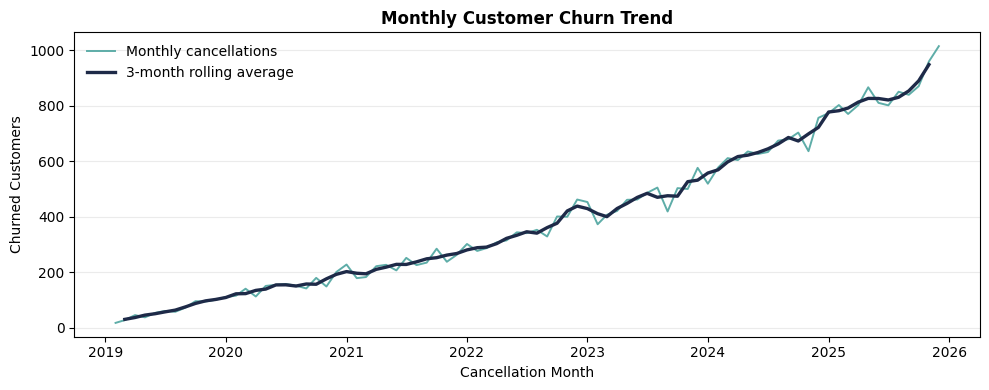

In [48]:
# Plotting and saving the monthly customer churn trend with a 3-month rolling average
monthly_churn['rolling_3m'] = monthly_churn['churned_customers'].rolling(3, center = True).mean()

plt.figure(figsize = (10, 4))

plt.plot(
    monthly_churn['cancellation_month'],
    monthly_churn['churned_customers'],
    color = LIGHT,
    linewidth = 1.4,
    label = 'Monthly cancellations'
)
plt.plot(
    monthly_churn['cancellation_month'],
    monthly_churn['rolling_3m'],
    color = DARK,
    linewidth = 2.4,
    label = '3-month rolling average'
)

plt.title('Monthly Customer Churn Trend', fontweight = 'bold')
plt.xlabel('Cancellation Month')
plt.ylabel('Churned Customers')
plt.legend(frameon = False)
plt.grid(axis = 'y', alpha = 0.25)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/monthly_churn_trend.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Key finding:** Cancellations climb across the observation window, tracking the growth of the subscriber base itself — annual signups rose from 5,664 in 2019 to 27,638 in 2025. Because the denominator is expanding at the same time, the raw count measures scale as much as deterioration. The rate-based segment breakdowns that follow are the reliable read on retention health; this chart establishes volume context, not a verdict.

### 5.2 Churn Rate by Subscription Plan

Compares churn across the three subscription tiers. Rate is used rather than raw counts so the plans compare fairly despite holding different customer volumes.

In [49]:
# Calculate the churn rate for each subscription plan
plan_churn_rate = (
    df_viz.groupby('plan_type', as_index = False)
    .agg(churn_rate = ('churn_flag', 'mean'))
    .sort_values('churn_rate', ascending = False)
    .reset_index(drop = True)
)

plan_churn_rate['churn_rate'] = (plan_churn_rate['churn_rate'] * 100).round(2)
plan_churn_rate

,plan_type,churn_rate
0,Basic,42.69
1,Standard,30.51
2,Premium,19.80


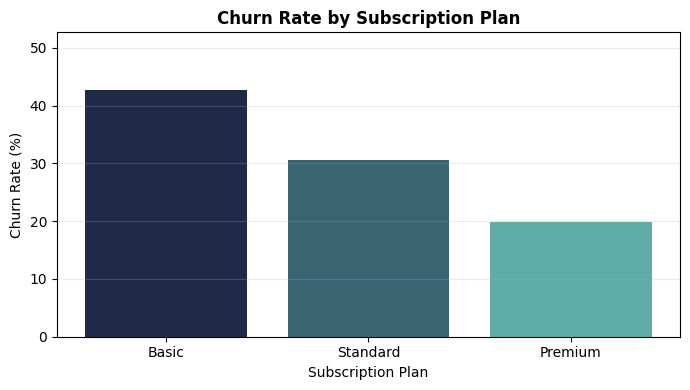

In [50]:
# Plot and save the churn rate by subscription plan
plt.figure(figsize = (7, 4))

plt.bar(
    plan_churn_rate['plan_type'],
    plan_churn_rate['churn_rate'],
    color = [DARK, MID, LIGHT]
)

plt.title('Churn Rate by Subscription Plan', fontweight = 'bold')
plt.xlabel('Subscription Plan')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, plan_churn_rate['churn_rate'].max() + 10)
plt.grid(axis = 'y', alpha = 0.25)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/churn_rate_by_plan.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Key finding:** Churn falls as plan value rises — **Basic 42.69%**, Standard 30.51%, Premium 19.80%. Basic customers are more than twice as likely to leave as Premium customers while generating $9.72 ARPU against $22.63. The entry tier is the weakest segment on both retention and revenue, making it the clearest target for intervention.

### 5.3 Churn Rate by State

Geographic view across all 51 US markets. The chart shows the 15 highest-churn states with their customer counts, since displaying every market at once obscures more than it reveals.

In [51]:
# Calculating churn rate and customer volume by state, keeping the 15 highest-churn states
state_churn_rate = (
    df_viz.groupby('state', as_index = False)
    .agg(
        churn_rate = ('churn_flag', 'mean'),
        customer_count = ('customerid', 'nunique')
    )
    .sort_values('churn_rate', ascending = False)
    .head(15)
    .sort_values('churn_rate')
    .reset_index(drop = True)
)

state_churn_rate['churn_rate'] = (state_churn_rate['churn_rate'] * 100).round(2)
state_churn_rate

,state,churn_rate,customer_count
0,Washington,33.26,2399
1,Maryland,33.57,1981
2,New Mexico,33.83,609
3,Colorado,34.78,1754
4,Hawaii,34.83,422
5,Illinois,35.37,3870
6,Massachusetts,36.25,2113
7,Utah,36.25,982
8,Nevada,36.63,950
9,Texas,37.24,8787


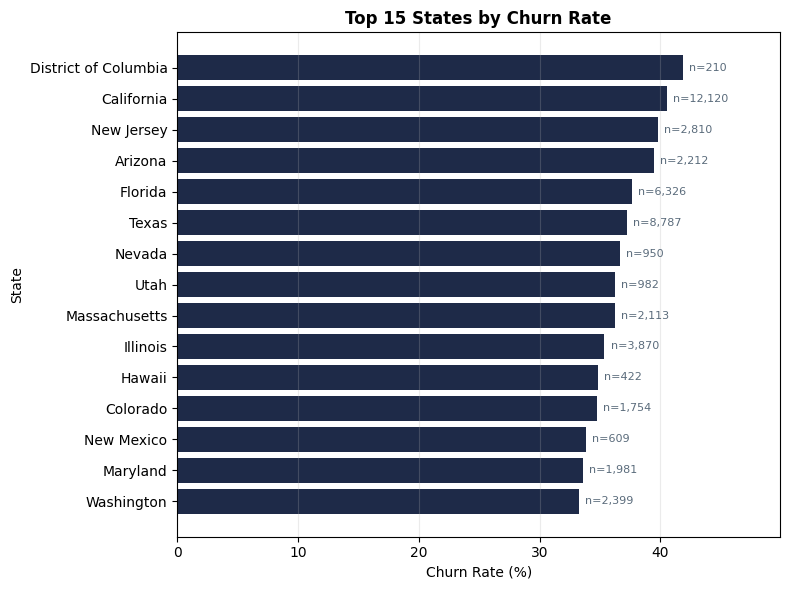

In [52]:
# Plotting and saving the churn rate for the 15 highest-churn states
plt.figure(figsize = (8, 6))

plt.barh(
    state_churn_rate['state'],
    state_churn_rate['churn_rate'],
    color = DARK
)

# Label each bar with how many customers it represents
for position, row in state_churn_rate.iterrows():
    plt.text(
        row['churn_rate'] + 0.5,
        position,
        f"n={row['customer_count']:,}",
        va = 'center',
        fontsize = 8,
        color = '#5A6B7B'
    )

plt.title('Top 15 States by Churn Rate', fontweight = 'bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('State')
plt.xlim(0, state_churn_rate['churn_rate'].max() + 8)
plt.grid(axis = 'x', alpha = 0.25)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/churn_rate_by_state.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Key finding:** Churn varies materially by market, from **15.52% in Vermont to 41.90% in the District of Columbia** — and the pattern is structural rather than random. The highest-churn markets are the most urbanised: DC, California (40.54%), New Jersey (39.82%), Arizona (39.47%) and Florida (37.62%). The lowest are rural: Vermont, Maine (19.02%) and Montana (19.52%). Dense urban markets give subscribers the most competing services and the least switching friction.

**California is the priority.** At 40.54% churn across **12,120 customers** it represents by far the largest absolute loss of any market — DC churns marginally higher but on only 210 customers. **Rate alone is not a priority ranking; rate multiplied by volume is**, which is why customer counts are printed on every bar.

### 5.4 Correlation Heatmap

Examines linear relationships among the churn-related metrics. Categorical fields are included, which requires converting them to numbers first — and *how* that conversion is done materially changes the result. These are encoded by business priority rather than alphabetically; the comparison below shows why that distinction matters.

In [53]:
# Encode ordered categories by business priority, not alphabetically
df_encoded = df_viz.copy()

df_encoded['plan_type'] = pd.Categorical(
    df_encoded['plan_type'], ['Basic', 'Standard', 'Premium'], ordered = True
).codes

df_encoded['contract_type'] = pd.Categorical(
    df_encoded['contract_type'], ['Monthly', 'Annual'], ordered = True
).codes

df_encoded['churn_risk'] = pd.Categorical(
    df_encoded['churn_risk'], ['low', 'med', 'high'], ordered = True
).codes

df_encoded[['plan_type', 'contract_type', 'churn_risk']].head()

,plan_type,contract_type,churn_risk
0,0,1,0
1,2,1,0
2,0,0,1
3,1,0,1
4,0,1,1


In [54]:
# Calculate correlations among selected churn-related metrics
correlation_data = df_encoded[
    [
        'monthly_charges',
        'cltv',
        'churn_score',
        'churn_flag',
        'csat_score',
        'complaint_count',
        'escalation_flag',
        'plan_type',
        'contract_type'
    ]
]

correlation_matrix = correlation_data.corr().round(2)
correlation_matrix

,monthly_charges,cltv,churn_score,churn_flag,csat_score,complaint_count,escalation_flag,plan_type,contract_type
monthly_charges,1.00,0.27,-0.38,-0.24,0.05,-0.10,-0.10,0.96,0.16
cltv,0.27,1.00,-0.33,-0.28,0.15,-0.13,-0.13,0.42,0.23
churn_score,-0.38,-0.33,1.00,0.38,-0.35,0.26,0.39,-0.39,-0.68
churn_flag,-0.24,-0.28,0.38,1.00,-0.16,0.14,0.20,-0.18,-0.32
csat_score,0.05,0.15,-0.35,-0.16,1.00,-0.14,-0.43,0.06,0.12
complaint_count,-0.10,-0.13,0.26,0.14,-0.14,1.00,0.05,-0.11,-0.14
escalation_flag,-0.10,-0.13,0.39,0.20,-0.43,0.05,1.00,-0.11,-0.19
plan_type,0.96,0.42,-0.39,-0.18,0.06,-0.11,-0.11,1.00,0.16
contract_type,0.16,0.23,-0.68,-0.32,0.12,-0.14,-0.19,0.16,1.00


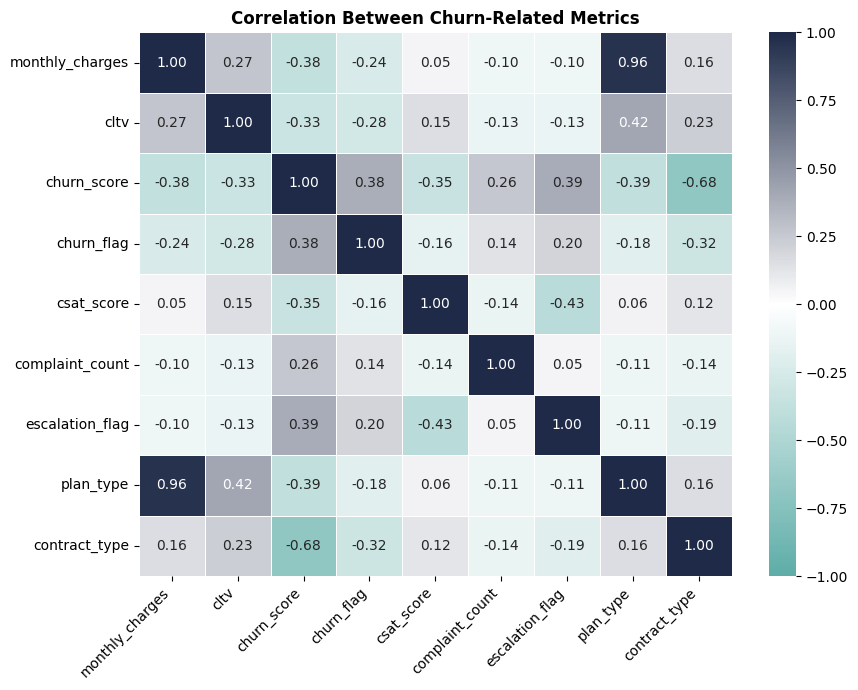

In [55]:
# Plotting and saving the correlation heatmap
from matplotlib.colors import LinearSegmentedColormap

# Diverging colourmap built from the project palette: teal (negative) to navy (positive)
churn_cmap = LinearSegmentedColormap.from_list('churn', [LIGHT, '#FFFFFF', DARK])

plt.figure(figsize = (9, 7))

sns.heatmap(
    correlation_matrix,
    annot = True,
    fmt = '.2f',
    cmap = churn_cmap,
    center = 0,
    vmin = -1,
    vmax = 1,
    linewidths = 0.5
)

plt.xticks(rotation = 45, ha = 'right')
plt.title('Correlation Between Churn-Related Metrics', fontweight = 'bold')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/correlation_heatmap.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Key finding:** Churn correlates most strongly with **churn score (0.38)**, **contract type (−0.32)**, **lifetime value (−0.28)**, monthly charges (−0.24) and escalation status (0.20). CSAT (−0.16), plan tier (−0.18) and complaint volume (0.14) contribute in the expected directions.

Correlations are moderate rather than extreme, which is what genuine behavioural data looks like — no single variable determines churn, and the drivers combine.

In [56]:
# Compare priority-ordered encoding against a naive alphabetical encoding
risk_ordered = pd.Categorical(df_viz['churn_risk'], ['low', 'med', 'high'], ordered = True).codes
risk_alphabetical = df_viz['churn_risk'].astype('category').cat.codes

contract_ordered = pd.Categorical(df_viz['contract_type'], ['Monthly', 'Annual'], ordered = True).codes
contract_alphabetical = df_viz['contract_type'].astype('category').cat.codes

encoding_comparison = pd.DataFrame({
    'column': ['churn_risk', 'contract_type'],
    'corr_ordered': [
        pd.Series(risk_ordered).corr(df_viz['churn_flag']),
        pd.Series(contract_ordered).corr(df_viz['churn_flag'])
    ],
    'corr_alphabetical': [
        risk_alphabetical.corr(df_viz['churn_flag']),
        contract_alphabetical.corr(df_viz['churn_flag'])
    ]
}).round(3)

encoding_comparison

,column,corr_ordered,corr_alphabetical
0,churn_risk,0.356,-0.139
1,contract_type,-0.322,0.322


**Why this matters:** encoding `churn_risk` alphabetically produces `high=0, low=1, med=2` — meaningless as an ordinal scale — and **reverses the sign of its correlation with churn, from +0.356 to −0.139**. The same reversal occurs for `contract_type` (−0.322 becomes +0.322). Encoding order is not a cosmetic choice; done carelessly it inverts the conclusion a stakeholder would draw.

### 5.5 Churn Rate by Contract Type

Compares churn between monthly and annual contracts — the single most controllable variable in the dataset, since contract terms are set by the business at the point of sale.

In [57]:
# Calculating churn rate and customer volume by contract type
contract_churn_rate = (
    df_viz.groupby('contract_type', as_index=False)
    .agg(
        churn_rate = ('churn_flag', 'mean'),
        customer_count = ('customerid', 'nunique')
    )
    .sort_values('churn_rate', ascending = False)
    .reset_index(drop = True)
)

contract_churn_rate['churn_rate'] = (
    contract_churn_rate['churn_rate'] * 100
).round(2)

contract_churn_rate

,contract_type,churn_rate,customer_count
0,Monthly,50.8,40966
1,Annual,20.1,59034


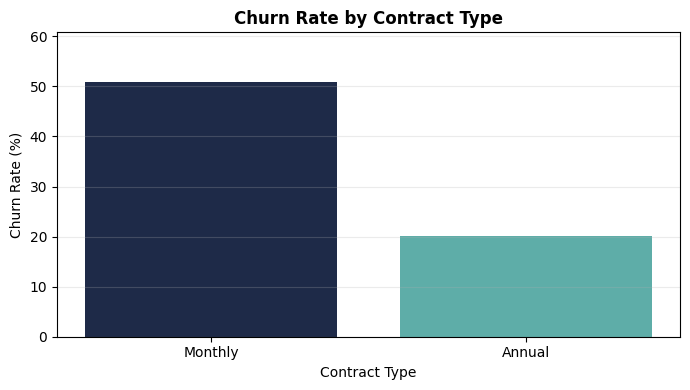

In [58]:
# Plotting and saving the churn rate by contract type
plt.figure(figsize = (7, 4))

plt.bar(
    contract_churn_rate['contract_type'],
    contract_churn_rate['churn_rate'],
    color = [DARK, LIGHT]
)

plt.title('Churn Rate by Contract Type', fontweight = 'bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, contract_churn_rate['churn_rate'].max() + 10)
plt.grid(axis = 'y', alpha = 0.25)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/churn_rate_by_contract.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Key finding:** Monthly-contract customers churn at **50.80%** against **20.10%** for annual — a 2.5× gap across 40,966 and 59,034 customers. Monthly contracts hold 38.4% of MRR but account for **62.1%** of all revenue lost to churn ($269,154 of $433,107). Migrating monthly subscribers onto annual terms is the highest-leverage retention action available.

### 5.6 Tenure Distribution

Compares how long retained and churned customers have been subscribed. With 100,000 customers the full distribution is visible, which a summary average conceals.

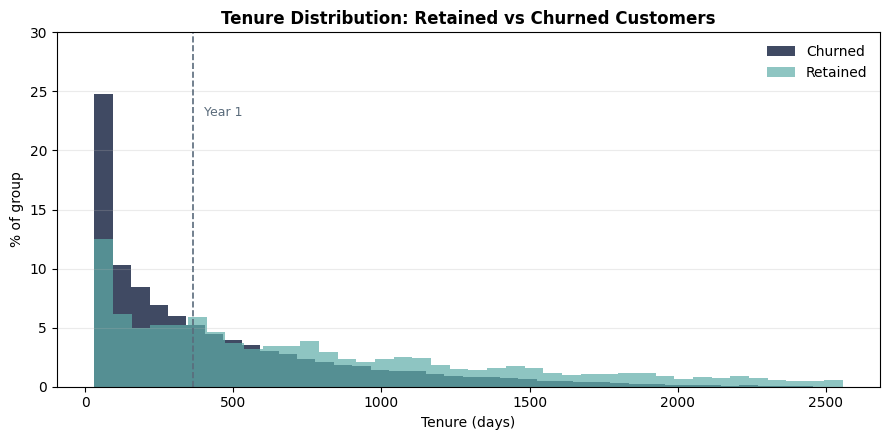

In [59]:
# Comparing tenure distributions for retained and churned customers
df_viz['tenure_days'] = np.where(
    df_viz['cancellation_date'].notna(),
    (df_viz['cancellation_date'] - df_viz['subscription_start_date']).dt.days,
    (AS_OF_DATE - df_viz['subscription_start_date']).dt.days
)

churned_tenure = df_viz.loc[df_viz['churn_flag'] == 1, 'tenure_days']
retained_tenure = df_viz.loc[df_viz['churn_flag'] == 0, 'tenure_days']

# Plot each group as a percentage of itself, so the shapes compare fairly
# despite the retained group being roughly twice the size
plt.figure(figsize = (9, 4.5))

plt.hist(
    churned_tenure, bins = 40, alpha = 0.85, label = 'Churned', color = DARK,
    weights = np.ones(len(churned_tenure)) / len(churned_tenure) * 100
)
plt.hist(
    retained_tenure, bins = 40, alpha = 0.70, label = 'Retained', color = LIGHT,
    weights = np.ones(len(retained_tenure)) / len(retained_tenure) * 100
)

plt.axvline(365, color = '#5A6B7B', linestyle = '--', linewidth = 1.2)
plt.text(400, plt.ylim()[1] * 0.88, 'Year 1', fontsize = 9, color = '#5A6B7B')

plt.title('Tenure Distribution: Retained vs Churned Customers', fontweight = 'bold')
plt.xlabel('Tenure (days)')
plt.ylabel('% of group')
plt.ylim(0, 30)
plt.legend(frameon = False)
plt.grid(axis = 'y', alpha = 0.25)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/tenure_distribution.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Key finding:** Shown as a share of each group, the two distributions separate clearly. **38.6% of churned customers left within their first 180 days**, against 20.7% of retained customers still sitting in that band — while at the other end, **15.6% of retained customers have passed four years versus just 4.1% of churners.** Median tenure is **275 days for churned against 570 for retained**.

This is the front-loaded churn hazard: risk is highest immediately after signup and falls steadily as customers establish the habit, which makes the first 12 months the decisive retention window.

### 5.7 Multi-Dimensional Segment Comparison

A single view combining plan tier and contract type. A grouped bar chart (`sns.barplot`) places the monthly and annual bars side by side within each plan tier, so both drivers can be read at once — useful for confirming whether the drivers identified separately actually compound.

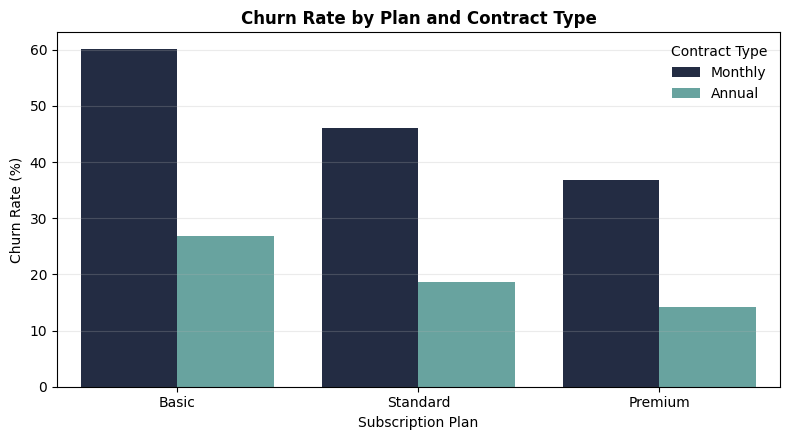

,plan_type,contract_type,churn_rate
0,Basic,Annual,26.91
1,Basic,Monthly,60.09
2,Premium,Annual,14.22
3,Premium,Monthly,36.82
4,Standard,Annual,18.58
5,Standard,Monthly,46.02


In [60]:
# Comparing churn rate across plan and contract type in one view
segment_summary = (
    df_viz.groupby(['plan_type', 'contract_type'], as_index = False)
    .agg(churn_rate = ('churn_flag', 'mean'))
)
segment_summary['churn_rate'] = (segment_summary['churn_rate'] * 100).round(2)

plt.figure(figsize = (8, 4.5))

sns.barplot(
    data = segment_summary,
    x = 'plan_type',
    y = 'churn_rate',
    hue = 'contract_type',
    order = ['Basic', 'Standard', 'Premium'],
    hue_order = ['Monthly', 'Annual'],
    palette = [DARK, LIGHT]
)

plt.title('Churn Rate by Plan and Contract Type', fontweight = 'bold')
plt.xlabel('Subscription Plan')
plt.ylabel('Churn Rate (%)')
plt.legend(title = 'Contract Type', frameon = False)
plt.grid(axis = 'y', alpha = 0.25)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/churn_by_plan_and_contract.png', dpi = 300, bbox_inches = 'tight')
plt.show()

segment_summary

**Key finding:** The two drivers compound. Within every plan tier, monthly contracts churn far more than annual — the worst cell is **Basic on a monthly contract at 60.09%**, against **Premium on an annual contract at 14.22%**, a fourfold gap.

The critical read is the diagonal: an **annual Basic** customer (26.91%) retains substantially better than a **monthly Premium** one (36.82%). **Contract structure outweighs plan tier as a retention lever**, which reframes the action from "fix the Basic plan" to "change the terms Basic customers are sold on."

## 6. Pivot Table Analysis

Pivot tables combine several metrics into a single comparison. This section summarises the three core commercial metrics — churn rate, customer volume, and monthly revenue — by subscription plan, giving a combined view of retention and revenue weight in one table.

### 6.1 Subscription Plan Performance Summary

Churn rate, customer volume, and total monthly revenue by plan, giving a combined view of retention and commercial weight.

In [61]:
# Summarizing key performance metrics by subscription plan
plan_performance_pivot = pd.pivot_table(
    data = df_viz,
    index = 'plan_type',
    values = [
        'churn_flag',
        'customerid',
        'monthly_charges'
    ],
    aggfunc = {
        'churn_flag': 'mean',
        'customerid': 'nunique',
        'monthly_charges': 'sum'
    }
).reset_index()

plan_performance_pivot['churn_flag'] = (plan_performance_pivot['churn_flag'] * 100).round(2)

plan_performance_pivot = plan_performance_pivot.rename(
    columns = {
        'churn_flag': 'churn_rate',
        'customerid': 'customer_count',
        'monthly_charges': 'total_monthly_charges'
    }
)
plan_performance_pivot

,plan_type,churn_rate,customer_count,total_monthly_charges
0,Basic,42.69,36511,354992.31
1,Premium,19.80,21291,481734.95
2,Standard,30.51,42198,657931.28


**Key finding:** Basic carries the highest churn at **42.69%** on **$354,992** of monthly revenue, while Premium retains best at 19.80% on the highest revenue per user. Standard holds the largest customer base (42,198) at a moderate 30.51% and the largest revenue block ($657,931). Ranked by revenue actually at risk rather than rate alone, Standard and Basic together carry the bulk of the exposure.

## 7. Business Insights and Recommendations

The analysis identifies a consistent churn profile and a behavioural signal that precedes cancellation. The findings below translate the results into retention priorities, ordered by expected impact.

### 7.1 Key Business Insights

1. **Contract type is the strongest controllable driver.** Monthly-contract customers churn at **50.80%** against **20.10%** on annual. Monthly holds 38.4% of MRR but accounts for **62.1%** of revenue lost.

2. **The two drivers compound.** Basic on a monthly contract churns at **60.09%**; Premium on annual at **14.22%**. An annual Basic customer (26.91%) still outperforms a monthly Premium one (36.82%) — contract structure matters more than plan tier.

3. **Churn is concentrated in the low-value end.** Lifetime value correlates with churn at **−0.28**; churned customers average $187 CLTV against $372 for retained.

4. **Referral acquisition underperforms.** Referral customers churn at **45.81%** against 31.88% paid and 26.71% organic, while generating the lowest revenue of the three channels.

5. **Support contact is a reliable early-warning signal.** Counting only tickets filed before the outcome, churn rises from **29.09%** with no support contact, to 43.59% once a ticket is filed, to **67.77%** on escalation — a signal that arrives before cancellation.

6. **Risk is front-loaded in the lifecycle.** **58.5%** of churn occurs within the first year; churned customers have a median tenure of 275 days against 570 for retained.

7. **Geography follows urbanisation.** Rates span 15.52% (Vermont) to 41.90% (DC), with the most urbanised markets churning hardest. California is the largest absolute exposure — 40.54% churn across 12,120 customers.

8. **First-contact resolution is weak.** **45.25%** of support-contacting customers had their most recent (pre-outcome) ticket escalated — an operational problem independent of churn that feeds the highest-risk cohort.

### 7.2 Recommended Actions

1. **Migrate monthly subscribers to annual contracts.** The highest-leverage action available. Monthly contracts drive 62.1% of lost revenue while holding 38.4% of MRR. Prioritise the Basic-monthly cell at 60.09% churn. Pilot an annual-conversion incentive for these customers and set the break-even discount from the experimental retention lift, contribution margin, and expected customer lifetime rather than benchmarking it against the cumulative churn rate.

2. **Default referral signups to annual terms.** Referral churn of 45.81% on the lowest revenue base suggests the channel is optimised for acquisition volume rather than retained value. Tie referral incentives to annual commitment rather than signup alone.

3. **Trigger retention outreach at first support contact.** Churn rises sharply the moment a ticket is filed (29.09% → 43.59%) and reaches 67.77% on escalation. Route tickets from high-value or high-risk customers into a retention queue in parallel with normal support handling.

4. **Concentrate intervention in the first 12 months.** With 58.5% of churn occurring in year one and a churned median tenure of 275 days, onboarding and early-lifecycle engagement carry disproportionate return compared with broad-base retention spend.

5. **Audit first-contact resolution.** With 45.25% of support-contacting customers hitting an escalation on their latest ticket — and escalated tickets preceding a 67.77% churn rate — the support process is compounding churn risk. Establish whether the driver is product defect, policy friction, or agent authority, and track escalation rate as a retention metric.

6. **Prioritise dense urban markets, volume-weighted.** California (40.54%, 12,120 customers) is the single largest absolute loss, followed by Florida and New Jersey. Competition intensity in these markets argues for differentiated retention offers rather than a national campaign.

7. **Reposition the Basic tier.** Basic churns at 42.69% on the lowest ARPU ($9.72) and lifetime value ($171). Determine whether it under-delivers value or attracts low-intent customers, and consider restructuring it as a trial step into Standard.